In [1]:
# import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew



# load data
df = pd.read_csv("../data/2_dataset.csv", low_memory=False)
# df that we will use for EDA
eda_df = df.copy()

# Exploratory Data Analysis (EDA) 

## Preface 

Previous treatments :

* 1_dataset_engineering.ipynb

The explanaition of all the variables of the dataset is done in the notebook : 1_dataset_engineering.ipynb

## Objective

Our goal here is to analyze the existing variables in relation to our target (delay in minutes of a bus) to determine what treatments we will do to our data to reveal the patterns that we found.

## Table of contents

## Dataset global overview

Before getting into the univariate analysis of each one of our dataset's variables, we will first observe the global overview of the dataset.

### Dataset format

In [2]:
df.shape

(50913, 17)

We have 50913 entries for 17 variables. As mentionned previously the details for each variable can be found in `1_dataset_engineering.ipynb`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50913 entries, 0 to 50912
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ROUTE              50385 non-null  object 
 1   LOCAL_TIME         50913 non-null  object 
 2   WEEK_DAY           50913 non-null  object 
 3   DELAY              50913 non-null  int64  
 4   LOCAL_MONTH        50875 non-null  float64
 5   LOCAL_DAY          50875 non-null  float64
 6   TEMP               50866 non-null  float64
 7   DEW_POINT_TEMP     50866 non-null  float64
 8   HUMIDEX            10798 non-null  float64
 9   PRECIP_AMOUNT      50866 non-null  float64
 10  RELATIVE_HUMIDITY  50866 non-null  float64
 11  STATION_PRESSURE   50866 non-null  float64
 12  VISIBILITY         50856 non-null  float64
 13  WEATHER_ENG_DESC   7517 non-null   object 
 14  WINDCHILL          5388 non-null   float64
 15  WIND_DIRECTION     49228 non-null  float64
 16  WIND_SPEED         508

### Missing data

In [4]:
def missing_data(df):
    # Calculate missing values and proportions
    missing_count = df.isna().sum()
    missing_percent = (df.isna().mean() * 100).round(2)

    # Combine into one DataFrame
    missing_df = pd.DataFrame({
        'Missing Values': missing_count,
        'Percentage (%)': missing_percent
    })

    return missing_df

missing_data(eda_df)

,Missing Values,Percentage (%)
ROUTE,528,1.04
LOCAL_TIME,0,0.00
WEEK_DAY,0,0.00
DELAY,0,0.00
LOCAL_MONTH,38,0.07
LOCAL_DAY,38,0.07
TEMP,47,0.09
DEW_POINT_TEMP,47,0.09
HUMIDEX,40115,78.79
PRECIP_AMOUNT,47,0.09


#### Handling HUMIDEX and WINDCHILL

We notice that we have a lot of missing data in the following variables :

* `HUMIDEX` (78.79% of missing data)
* `WINDCHILL` (89.42% of missing data)

These are index calculated by the providers of the dataset. In their documentation, they give the formulas for both indexes :

* Humidex :
    * With :
        - $T_{\text{air}}$ : air temperature (in Celsius)
        - $T_{\text{dewpoint}}$ : dewpoint temperature (in Kelvin)
        - $e$ : vapour pressure (in hPa)

$$ humidex = T_{\text{air}} + h $$

$$ h = 0.5555 \times (e - 10.0) $$

$$ e = 6.11 \exp\left[ 5417.7530 \times \left( \frac{1}{273.15} - \frac{1}{T_{\text{dewpoint}}} \right) \right] $$

$$ \exp = 2.71828 $$

*  Windchill :
    * With :
        - $T_{\text{air}}$ : air temperature (in Celsius)
        - $V_{\text{10m}}$ : wind speed at 10 meters (in kilometers per hour)
    * For when $T_{\text{air}} \le 0 \text{°C}$ and $V_{\text{10m}} \ge 5 \text{km/h}$ 
        1. $windchill = 13.12 + 0.6215 T_{\text{air}} - 11.37 V_{\text{10m}}^{0.16} + 0.3965 T_{\text{air}} V_\text{10m}^{0.16} $
    * For when $T_{\text{air}} \le 0 \text{°C}$ and $0 < V_{\text{10m}} < 5 \text{km/h}$
        
        2. $windchill = T_{\text{air}} + ((-1.59 + 0.1345T_{\text{air}})/5) \times V_{\text{10m}}$

It happens that we have all the required data to calculate the humidex and windchill indexes. We can fill in those gaps by calculating these values manually. However, it is important to note that our value for the windspeed is *usually* measured at 10 meters and that this index may be calculated at a different altitude. Furthermore, not all entries will meet the requirements for calculating the winchill index, we still may have a high proportion of missing data.

> Note : In the original dataset, the humidex and windchill are rounded to the nearest degree. To increase precision we recalculate even the non-missing values. Furthermore, in the original dataset, the humidex was provided only when the air temperature was greater or equal to 20°C and the humidex value is at least 1 degree greater than the air temperature.

We replace the data with our formulas and look how much data is missing :

In [5]:
def humidex(t_air, t_dewpoint):
    exp = 2.71828 # we use the exponential value provided by the documentation, we could be more precise by using numpy.exp(1)
    t_dewpoint += 273.15 # celsius to kelvin
    e = 6.11 * exp**(5417.7530 * ((1/273.15) - (1/t_dewpoint)))  # in hPa
    h = 0.5555 * (e - 10.0)
    humidex = t_air + h
    return humidex

def wind_chill(t_air, windspeed):
    if t_air <= 0 and windspeed >= 5:
        return 13.12 + 0.6215 * t_air - 11.37 * (windspeed**0.16) + 0.3965 * t_air * (windspeed**0.16)
    if t_air <= 0 and 0 < windspeed and windspeed < 5:
        return t_air + ((-1.59 + 0.1345 * t_air) / 5) * windspeed
    else:
        return np.nan

# Recalculate HUMIDEX and WIND_CHILL
eda_df["HUMIDEX"] = eda_df.apply(lambda row: humidex(row['TEMP'], row['DEW_POINT_TEMP']), axis=1)
eda_df["WINDCHILL"] = eda_df.apply(lambda row: wind_chill(row['TEMP'], row['WIND_SPEED']), axis=1)

# Show the empty values after recalculation
missing_data(eda_df[['HUMIDEX', 'WINDCHILL']])

,Missing Values,Percentage (%)
HUMIDEX,47,0.09
WINDCHILL,45525,89.42


We notice that the the humidex now only has 0.09% of it's data missing while the windchill stays at 89.42%.

> [TODO] FIND OUT WHAT TO DO WITH WINDCHILL. FOR NOW NO ACTIONS TAKEN

With these two special cases taken care of, we can move on to the next one.

#### Handling the missing WEATHER_ENG_DESC values

Another special case is the one of the weather description. This variable has 85.24% of it's data missing. However, according to the source documentation, this is not due to a lack of data but rather a lack of special event. So no data means no special event. Hence, we will replace all the missing values by the value "Clear".

> Note: the value "Clear" can be missleading as it could be interpreted as a clear sky. Here it just means that there are no special event, not that the sky isn't cloudy. 


In [6]:
# Replace missing WEATHER_ENG_DESC by 'Clear'
eda_df['WEATHER_ENG_DESC'] = eda_df['WEATHER_ENG_DESC'].fillna('Clear')
missing_data(eda_df[['WEATHER_ENG_DESC']])

,Missing Values,Percentage (%)
WEATHER_ENG_DESC,0,0.0


Now that all the special cases are out of the way, we can analyse the missing data on the other variables.

#### Dropping missing ROUTE values

Amongst the other variables two others stand out :

* `WIND_DIRECTION` (3.31% of missing data) 
* `ROUTE` (1.04% of missing data)

The missing data for the wind direction isn't a big problem and can be kept in the dataset. However, the data missing for the route is a bit more complex. We can't predict the bus delay without knowing what route is concerned. We should drop this variable and keep the other variables.

In [7]:
eda_df = eda_df.dropna(subset=['ROUTE'])
# Verify the result
print(f"Shape after dropping missing ROUTE values: {eda_df.shape} / previous shape: {df.shape} (dropped {df.shape[0] - eda_df.shape[0]} rows)")

Shape after dropping missing ROUTE values: (50385, 17) / previous shape: (50913, 17) (dropped 528 rows)


#### Removing rows with missing weather data

Another compelling point is the fact that 47 rows seem to be missing weather data (even after the recalculations, the humidex has 47 rows of missing data). We want to verify if this recurring number is just a coïncidence or if some rows are actually missing nearly all their weather data.

In [8]:
# Get the columns that have 47 or less missing data 
missing_data_df = eda_df.loc[:, eda_df.isna().sum() <= 47].isna()

# Get rows that have at least one missing value
rows_with_missing = eda_df[missing_data_df.any(axis=1)]

print(f"Number of rows with missing values: {len(rows_with_missing)}")

Number of rows with missing values: 47


With this verification, we could have had more than 47 rows concerned by the missing data. But by having precisely 47 rows concerned, we can confirm our suspicion that these 47 rows are missing a lot of their dataata. We are not interested by these rows since they proveid very few information. These 47 rows representing a very small amount of data relative to the entire dataset, we can drop them. 

In [9]:
before_drop_shape = eda_df.shape
# Dropping the 47 rows with missing data
eda_df = eda_df.drop(rows_with_missing.index)

# Verify the result
print(f"Shape after dropping rows with missing data: {eda_df.shape} / previous shape: {before_drop_shape} (dropped {before_drop_shape[0] - eda_df.shape[0]} rows)")

Shape after dropping rows with missing data: (50338, 17) / previous shape: (50385, 17) (dropped 47 rows)


To end up our global overview and preparation, we verify the dimensions of our dataset and the missing data in it. To facilitate possible analysis of the EDA data in other scripts later on, we create a new file named `3_eda_dataset.csv`.

In [10]:
print(f"Final shape of the dataset: {eda_df.shape}")

# Save the cleaned EDA dataset
eda_df.to_csv("../data/3_eda_dataset.csv", index=False)

# Verify missing data after all the cleaning
missing_data(eda_df)

Final shape of the dataset: (50338, 17)


,Missing Values,Percentage (%)
ROUTE,0,0.00
LOCAL_TIME,0,0.00
WEEK_DAY,0,0.00
DELAY,0,0.00
LOCAL_MONTH,0,0.00
LOCAL_DAY,0,0.00
TEMP,0,0.00
DEW_POINT_TEMP,0,0.00
HUMIDEX,0,0.00
PRECIP_AMOUNT,0,0.00


With the global overview and preparation of the data done, we can move on to the univariate analysis od our data.

### Duplicate data

Since this data is already cleaned, we can start by analysing the data to find out if there are any duplicate data.

No duplicates should appear since every incident is tied to an precise hour and a bus route.

In [11]:
# Finding the numner of duplicate rows
duplicate_rows = eda_df[eda_df.duplicated()].shape[0]
print(f"Number of duplicate rows: {duplicate_rows}")

# If there are duplicate rows, we drop them
if duplicate_rows > 0:
    eda_df = eda_df.drop_duplicates()
    print(f"Shape after dropping duplicate rows: {eda_df.shape}")

Number of duplicate rows: 484
Shape after dropping duplicate rows: (49854, 17)


## Univariate analysis

### Target variable: DELAY

First and foremost, we start by analysing our target variable.

The `DELAY` variable represents the delay in minutes that the bus will have due to some conditions.
Hence, we are going to predict a discrete numerical value, this means that we are tackling a **regression problem**.

Knowing this, we move on to an overview of the statistics of our target variable.

In [12]:
# Basic statistics
print("Basic statistics :")
print(eda_df['DELAY'].describe())

# Unique values count
print("\nUnique values count :")
print(eda_df['DELAY'].value_counts().sort_values())

# Missing values
print("\nMissing values :", eda_df['DELAY'].isna().sum())


Basic statistics :
count    49854.000000
mean        20.671842
std         51.682555
min          0.000000
25%          9.000000
50%         11.000000
75%         20.000000
max        998.000000
Name: DELAY, dtype: float64

Unique values count :
DELAY
273       1
411       1
605       1
230       1
712       1
       ... 
9      2841
8      3555
0      3668
20     4217
10     9440
Name: count, Length: 489, dtype: int64

Missing values : 0


Being our target variable, it is important to make sure that the delay has no missing values. We indeed have no missing values.

We notice that the standard deviation is of 51 and that the difference between the 75th percentile and max value is of 978 while the difference in between the maximum value and the 75th percentile is of 20. We seem to have a lot of data spread out on the last 25 percents of our values.

To obtain a visual confirmation of our suspicion, we will plot a histogram of the distribution of `DELAY`.

> Note: we also notice that the 3 values the most present in this variable are 10, 20 and 0. These were probably rounded up by the vreators of the dataset.

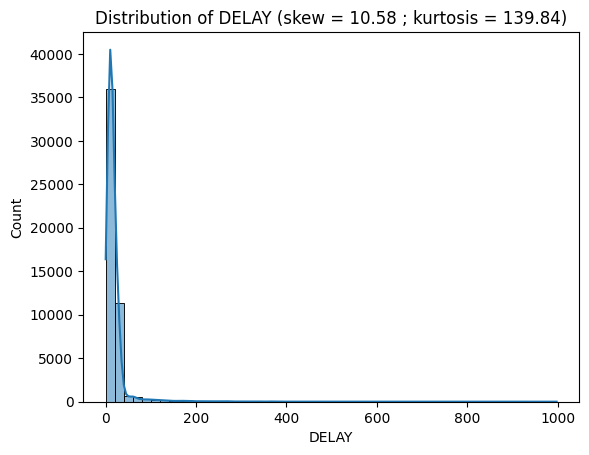

In [13]:
sns.histplot(eda_df['DELAY'], bins=50, kde=True)
plt.title(f"Distribution of DELAY (skew = {eda_df['DELAY'].skew():.2f} ; kurtosis = {eda_df['DELAY'].kurt():.2f})")
plt.show()

With a skewness of 10.58 and a kurtosis of 139.84, our data is is heavily skewed to the right. We observe on the histogram a very long tail on the right confirming the suspicions. However, it is hard to see how many outliers are present in our data. We will use a boxplot to visualize the distribution of `DELAY` and try to answer the question of the number of outliers.


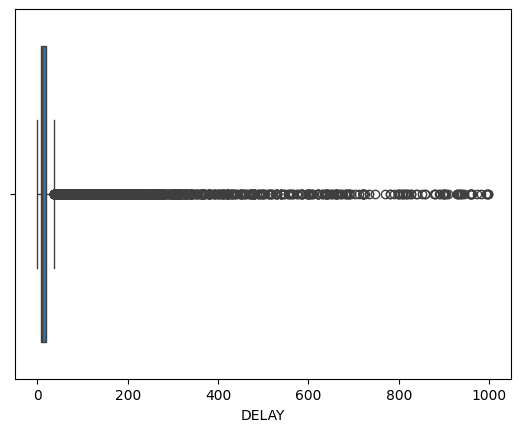

In [14]:
sns.boxplot(x=eda_df['DELAY'])
plt.show()

This boxplot very clearly shows that we have many outliers. 

This very high skewness (10.58) will be problematic in the rest of the EDA if we do not handle it now. We know that we won't have any negative values in our data but we still have zeroes. Since we have a lot of outliers, we cannot simply winsorize our data. To handle the skewness, we will use a log1p transformation on our variables.

We will store the result in a new variable called `DELAY_LOG1P`. This will allow us to compare the distribution of `DELAY` and `DELAY_LOG1P` in the same way during the bivariate and multivariate analysis.

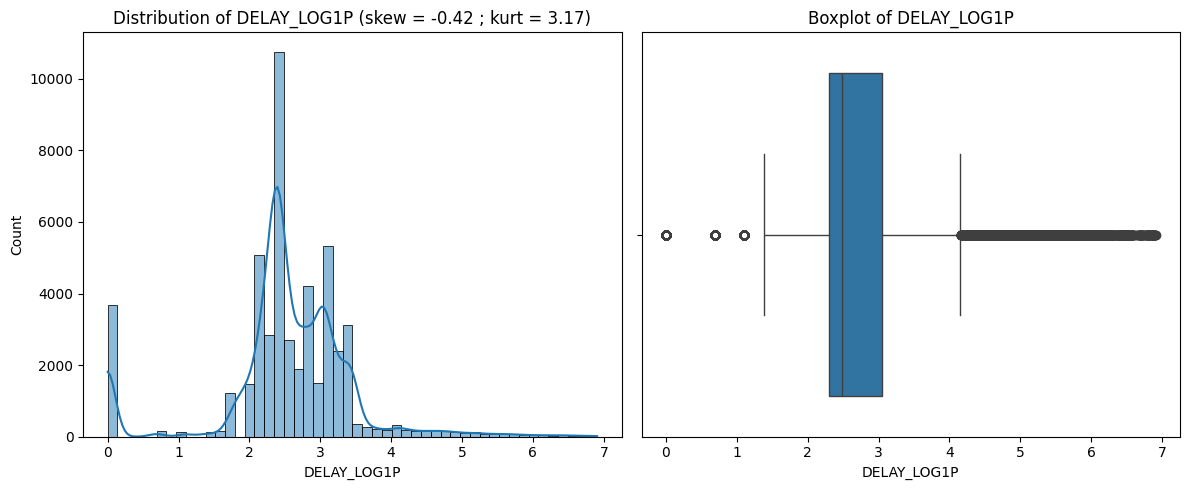

In [15]:
eda_df['DELAY_LOG1P'] = np.log1p(eda_df['DELAY']) 

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sns.histplot(eda_df['DELAY_LOG1P'], bins=50, kde=True, ax=axes[0])
axes[0].set_title(f"Distribution of DELAY_LOG1P (skew = {eda_df['DELAY_LOG1P'].skew():.2f} ; kurt = {eda_df['DELAY_LOG1P'].kurt():.2f})")

sns.boxplot(x=eda_df['DELAY_LOG1P'], ax=axes[1])
axes[1].set_title("Boxplot of DELAY_LOG1P")

plt.tight_layout()
plt.show()

With the skewness now down to -0.42 and the kurtosis being down 3.17, we have a more symmetrical distribution. However this distribution remains a bit leptokurticatic. Even so, this transformation made our data much more usable for later analysis. 

Just like `DELAY`, we will show an overview of this new variable's statistics.

In [16]:
# Basic statistics
print("Basic statistics :")
print(eda_df['DELAY_LOG1P'].describe())

# Missing values
print("\nMissing values :", eda_df['DELAY_LOG1P'].isna().sum())

Basic statistics :
count    49854.000000
mean         2.530090
std          0.971332
min          0.000000
25%          2.302585
50%          2.484907
75%          3.044522
max          6.906755
Name: DELAY_LOG1P, dtype: float64

Missing values : 0


### Temporal variables

#### LOCAL_TIME

> Note: this variable is used to identify the time of day at which the incident occured but that is not what the variable represents. This variable represents the time at which the incident was **reported**. This slight difference could be the cause of slight inaccuracies in the model.

The variable we are analyzing represents the time of the day at which the incident causing the delay was reported. It is given in the 'HH:MM' format. Before starting the analysis of this data, we should transform it in a datetime.

In [17]:
eda_df['LOCAL_TIME'] = pd.to_datetime(eda_df['LOCAL_TIME'], format='%H:%M').dt.time # transform the time in a datetime object

We also could use the hours of the day and minute separetly to better understand our data. 

In [18]:
eda_df['LOCAL_TIME_HOUR'] = pd.to_datetime(eda_df['LOCAL_TIME'], format='%H:%M:%S').dt.hour 
eda_df['LOCAL_TIME_MINUTE'] = pd.to_datetime(eda_df['LOCAL_TIME'], format='%H:%M:%S').dt.minute

With the data we newly created, we can observe the distribution of delays per hour and by minute.

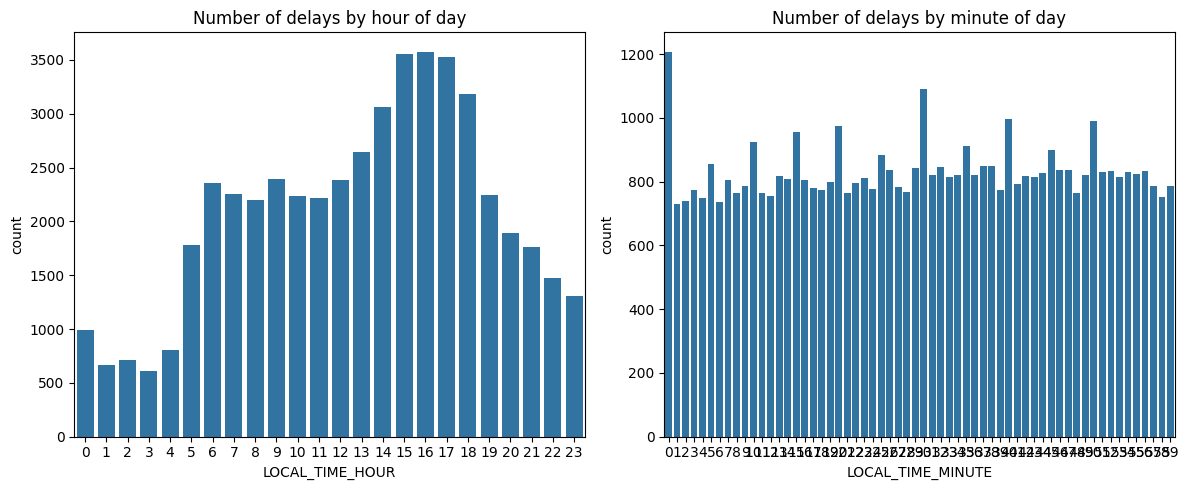

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot of delays by hour
sns.countplot(x='LOCAL_TIME_HOUR', data=eda_df, ax=axes[0])
axes[0].set_title('Number of delays by hour of day')

# Count plot of delays by minute
sns.countplot(x='LOCAL_TIME_MINUTE', data=eda_df, ax=axes[1])
axes[1].set_title('Number of delays by minute of day')

plt.tight_layout()
plt.show()

First of all, we notice that more delays occur around the 15th to 17th hours of the day and less between the 1st to the 4th. This seems coherent since lesser buses should be in activity at night than during the day. 

Another observation that can be made ist that the number of delays increases drastically starting at the 5th hour and decreases at the 19th. This seems once again coherent about what we know about the lifestyle of the average individual. By the 19th hour (7 pm) people came back from their workplace and less traffic is needed or delayed due to human activity.  

We can also detect a continuation from the 23rd hour to midnight, showing the cyclical nature of our data.

Concerning the minutes, not much can be said except for the fact that a lot of incident are being reported during the first minute of the hour or at the half of it. This is probably the result of the data being rounded up to the nearest "significant" minute. 

#### WEEK_DAY

The week day variable represents the day of the week (i.e "Monday", "Tuesday", ...) at which the incident was reported. 

We start by trying to figure out what days are the most represented in the dataset.

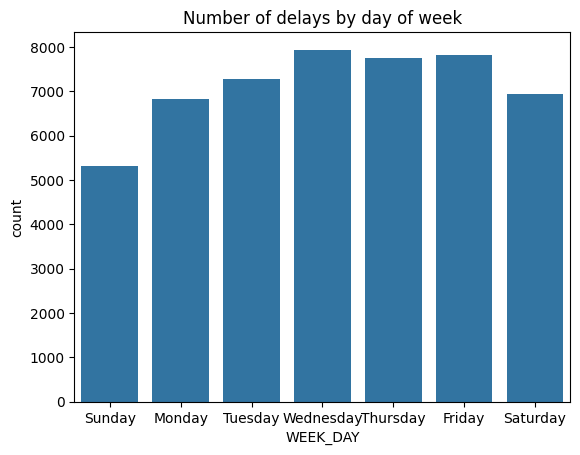

In [23]:
sns.countplot(x='WEEK_DAY', data=eda_df)
plt.title('Number of delays by day of week')

plt.show()

Once again, we notice that the life of the average individual can be found in this plotting. The five workdays have the most delays, with wednesday and friday having the most. Saturday has a lot of incidents too, this could be explained by it being the week-end and buses still having a normal schedule. The sunday is the day with the least incidents. Traditionnally the sunday is the day during which people relax, hece the bus schedules change and there are less buses so less incident reports.

We can also detect the cyclical pattern that occurs in temporal variables. It seems natural that saturday and sunday show a relation to one another since these two days are close in reality.

#### LOCAL_MONTH

The local month variable represents the month during which the incident was reported. The months are already encoded from 1 to 12.

Here again, we want to analyze the distribution of delays per month.

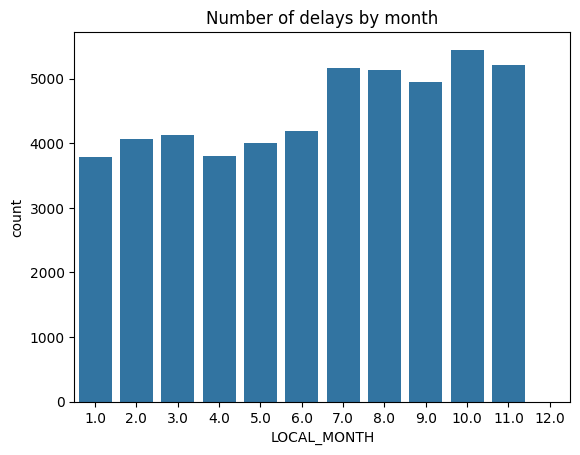

In [24]:
sns.countplot(x='LOCAL_MONTH', data=eda_df)
plt.title('Number of delays by month')

plt.show()